# Assessing credibility in Bayesian Networks structure learning
#### Authors: 
1. **Vitor Barth** (vitor.barth@usp.br) <br> University of Sao Paulo 

2. **Fábio Serrão** (carlos.maciel@unesp.br) <br> State University of Sao Paulo

3. **Carlos Maciel** (fserrao@ufscar.br) <br> Federal University of São Carlos

## 0. Dependencies

In [91]:
import cloudpickle

import arviz as az
import numpy as np
import pandas as pd
import pymc as pm

from datetime import timedelta
from timeit import default_timer as timer
from tqdm import tqdm

# Bayesian Networks Libs
from pgmpy.estimators import HillClimbSearch, BDeuScore
from pgmpy.models import BayesianNetwork

## 1. Model

### 1.1. States

In [61]:
STATES = { 
    0: "No Edge", 
    1: "A -> B", 
    2: "A <- B" 
}

### 1.2. Priors

#### True Fraction:
Serves as a hyperparameter of the Dirichlet-Multinomial model of the observed distributions. 
<br> The *posterior* is expected to model the true distribution of each state.

* **Distribution:** Dirichlet 
* **Parameters:** 
    - $\alpha$: Concentration
    <br> *Default*: `[1, 1, 1]` 

#### Concentration:
Will be used as a hyperparameter of the Dirichlet-Multinomial *posterior* model.

* **Distribution:** Log-Normal 
* **Parameters:** 
    - $\mu$: Logarithm of the Location
      <br> *Default*: `1`
    - $\sigma$: Logarithm of the Scale.
      <br> *Default*: `1`

#### Observed Fraction:
The Multinomial model of the observed distributions of each state.

* **Model:** Dirichlet-Multinomial 
* **Parameters:** 
    - $n$: Number of observations
    - $a$: Observed concentration of each state
      <br> *Default*: `true_fraction * concentration$`

In [80]:
TRUE_FRACTION_OF_EACH_STATE_ALPHA = [1/3, 1/3, 1/3]
CONCENTRATION_MU = 1.5
CONCENTRATION_SIGMA = 1.5

### 1.3 Learning the Distributions

In [90]:
"""
"""
def learn_edge_distribution(observations,
                            edge=[],
                            destination_folder="", 
                            experiment_identifier="", 
                            mcmc_alg=pm.NUTS, 
                            chains=10, 
                            burnin=10000, 
                            draws=10000, 
                            nthreads=4):
    
    if (destination_folder != "" and len(edge) != 2):
        raise Exception("The edge must be indicated when saving the model") 

    num_observations = len(observations)
    
    with pm.Model() as model:            
        frac = pm.Dirichlet("expected_fraction_of_observations", 
                            a=TRUE_FRACTION_OF_EACH_STATE_ALPHA)
        
        conc = pm.Lognormal("concentration", 
                            mu=CONCENTRATION_MU, 
                            sigma=CONCENTRATION_SIGMA)

        
        counts = pm.DirichletMultinomial(
            "observed_counts", 
            n=1,
            a=frac * conc, 
            shape=(num_observations, 3), 
            observed=observations
        )

        trace = pm.sample(chains=chains, 
                          tune=burnin, 
                          draws=draws, 
                          step=mcmc_alg(), 
                          return_inferencedata=False, 
                          cores=nthreads)

        # Saves if a destination is passed
        if (destination_folder != ""):
            posteriori = cloudpickle.dumps({
                            'model': model, 
                            'experiment_identifier': experiment_identifier,
                            'edge': edge,
                            'chains': chains,
                            'burnin': burnin,
                            'draws': draws,
                            'observations': observations,
                            'priors': {
                                'expected_fraction_of_observations_alpha': TRUE_FRACTION_OF_EACH_STATE_ALPHA,
                                'concentration_mu': CONCENTRATION_MU,
                                'concentration_sigma': CONCENTRATION_SIGMA,
                            },
                            'expected_fraction_of_observations':  frac, 
                            'concentration': conc, 
                            'observed_counts': counts, 
                            'trace': trace_dm_explicit
                         })

            if (experiment_identifier != ""):
                experiment_identifier = experiment_identifier + '_'
            
            file = open(destination_folder + '/' + experiment_identifier + str(chains) + '_b' + str(burnin) + '_d'+ str(draws) + '_' + edge[0] + "-" + edge[1] + '.pickle', 
                        'wb')
            file.write(posteriori)
        
        return trace

#### 1.4 Counting the edges from a list of BNs

In [84]:
def count_edges(networks):
    edges = dict()

    for network in networks:
        for edge in list(network):
            edge = [edge[0], edge[1]]
            N1 = sorted(edge)[0]
            N2 = sorted(edge)[1]

            if (N1, N2) not in edges.keys():
                edges[(N1, N2)] = []
            
            if N1 == edge[0]:
                edges[(N1, N2)].append([0,1,0])
            else:
                edges[(N1, N2)].append([0,0,1])

    # Fill the non-existent edges with [1, 0, 0]
    for edge in edges.keys():
        difference = len(networks) - len(edges[edge])
        if difference > 0:
            edges[edge] = np.concatenate(
                [edges[edge], [[1,0,0] for i in range(difference)]]
            )
    
    return edges

## 2. Testing

### Scenario 1 - Simple Three Edge Model

The objective of this scenario is to verify if the model is indeed converging to the expected values. 
It is formed by 4 nodes ($A$, $B$, $C$ and $D$) where:

* P(A=T) = 0.5
* P(B=T | A=T) = 0.9
* P(B=T | A=F) = 0.5
* P(C=T | A=T) = 0.2
* P(C=T | A=F) = 0.8
* P(D=T | B=T, C=T) = 0.01
* P(D=T | B=T, C=F) = 0.1
* P(D=T | B=F, C=T) = 0.1
* P(D=T | B=F, C=F) = 1

where the expected model has the form

```
A -> B
A -> C
B -> D
C -> D
```

**Num. Samples**: 100_000

#### Step 1: Generate the variables

In [145]:
A = []
B = []
C = []
D = []

for i in range(100_000):
    A.append(
        (np.random.uniform(0,1) > 0.5)*1
    )

    if A[i] == 1: 
        B.append((np.random.uniform(0,1) > 0.1) * 1)
        C.append((np.random.uniform(0,1) > 0.8) * 1)
    else:
        B.append((np.random.uniform(0,1) > 0.5) * 1)
        C.append((np.random.uniform(0,1) > 0.2) * 1)
        
    if (B[i]==1 and C[i]==1):
        D.append((np.random.uniform(0,1) > 0.01)*1)
    elif ((B[i]==1 and not C[i]==1) or (C[i]==1 and not B[i]==1)):
        D.append((np.random.uniform(0,1) > 0.1)*1)
    else:
        D.append(0)

df_scenario_1 = pd.DataFrame({
    'A': A, 
    'B': B, 
    'C': C, 
    'D': D 
})

df_scenario_1

,A,B,C,D
0,0,0,1,1
1,1,0,0,0
2,0,0,1,1
3,0,0,1,1
4,1,1,1,1
...,...,...,...,...
99995,0,0,1,1
99996,0,1,1,1
99997,1,1,0,0
99998,0,0,1,1


##### Step 2: Hill Climb (BDeu Score)

In [146]:
start = timer()

scoring_method = BDeuScore(data=df_scenario_1)    
est = HillClimbSearch(data=df_scenario_1)
network = est.estimate(scoring_method=scoring_method, show_progress=True)

end = timer()
elapsed_time = timedelta(seconds=end-start)
print("Time: " + str(elapsed_time))
print(network.edges)

  0%|          | 0/1000000 [00:00<?, ?it/s]

Time: 0:00:00.094187
[('B', 'A'), ('C', 'A'), ('C', 'B'), ('D', 'B'), ('D', 'C')]


##### Step 3: Evaluate Hill-Climb

We have the above list of edges, but imagine we knew nothing about the system which originated the data. 
How would you know this is right?

##### Step 4: Divide the dataset in chunks and learn a BN for each chunk

In [160]:
NUM_CHUNKS = 1_000
CHUNK_LENGHT = 500

chunks = []
edges = []

for i in tqdm(range(NUM_CHUNKS)):
    chunks.append(
        df_scenario_1.sample(n=CHUNK_LENGHT, random_state=i)
    )
    
    scoring_method = BDeuScore(data=chunks[i])    
    est = HillClimbSearch(data=chunks[i])
    network = est.estimate(scoring_method=scoring_method, show_progress=False)
    edges.append(network.edges)

print(edges[0])
chunks[0]

100%|███████████████████████████████████████████| 1000/1000 [00:11<00:00, 84.17it/s]

[('B', 'A'), ('C', 'A'), ('C', 'B'), ('D', 'B'), ('D', 'C')]


,A,B,C,D
3582,1,1,1,1
60498,1,1,0,1
53227,1,1,0,1
21333,1,0,0,0
3885,1,1,0,1
...,...,...,...,...
85653,1,1,0,1
19532,0,0,1,1
46696,1,1,1,1
83944,0,1,1,1


In [179]:
set([str(x) for x in count_edges(edges)[('A', 'C')]])

{'[0, 0, 1]', '[0, 1, 0]'}

Multiprocess sampling (10 chains in 10 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (10 chains in 10 jobs)
NUTS: [expected_fraction_of_observations, concentration]
INFO:pymc.sampling.mcmc:NUTS: [expected_fraction_of_observations, concentration]


Output()

Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 11 seconds.
INFO:pymc.sampling.mcmc:Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 11 seconds.


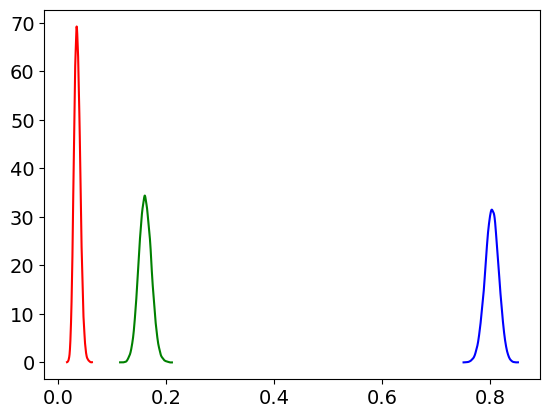

In [150]:
res = learn_edge_distribution(count_edges(edges)[('A', 'B')],
                        edge=['A', 'B'],
                        destination_folder="", 
                        experiment_identifier="", 
                        mcmc_alg=pm.NUTS, 
                        chains=10, 
                        burnin=1000, 
                        draws=5000, 
                        nthreads=10)

az.plot_dist(res["expected_fraction_of_observations"][:, 0], color='red');
az.plot_dist(res["expected_fraction_of_observations"][:, 1], color='b');
az.plot_dist(res["expected_fraction_of_observations"][:, 2], color='g');

Multiprocess sampling (10 chains in 10 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (10 chains in 10 jobs)
NUTS: [expected_fraction_of_observations, concentration]
INFO:pymc.sampling.mcmc:NUTS: [expected_fraction_of_observations, concentration]


Output()

Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 99 seconds.
INFO:pymc.sampling.mcmc:Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 99 seconds.


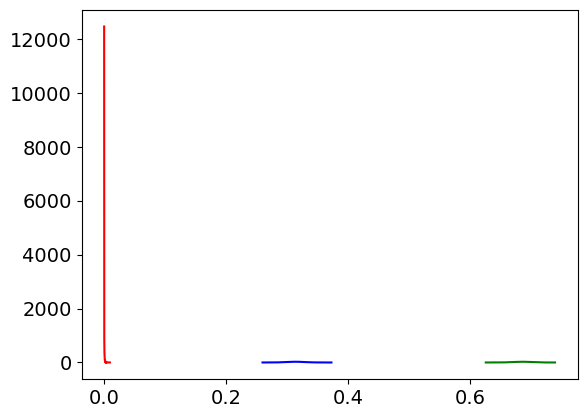

In [163]:
res = learn_edge_distribution(count_edges(edges)[('A', 'C')],
                        edge=['A', 'C'],
                        destination_folder="", 
                        experiment_identifier="", 
                        mcmc_alg=pm.NUTS, 
                        chains=10, 
                        burnin=1000, 
                        draws=5000, 
                        nthreads=10)

az.plot_dist(res["expected_fraction_of_observations"][:, 0], color='red');
az.plot_dist(res["expected_fraction_of_observations"][:, 1], color='b');
az.plot_dist(res["expected_fraction_of_observations"][:, 2], color='g');

Multiprocess sampling (10 chains in 10 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (10 chains in 10 jobs)
NUTS: [expected_fraction_of_observations, concentration]
INFO:pymc.sampling.mcmc:NUTS: [expected_fraction_of_observations, concentration]


Output()

Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 38 seconds.
INFO:pymc.sampling.mcmc:Sampling 10 chains for 1_000 tune and 5_000 draw iterations (10_000 + 50_000 draws total) took 38 seconds.
There were 944 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:There were 944 divergences after tuning. Increase `target_accept` or reparameterize.


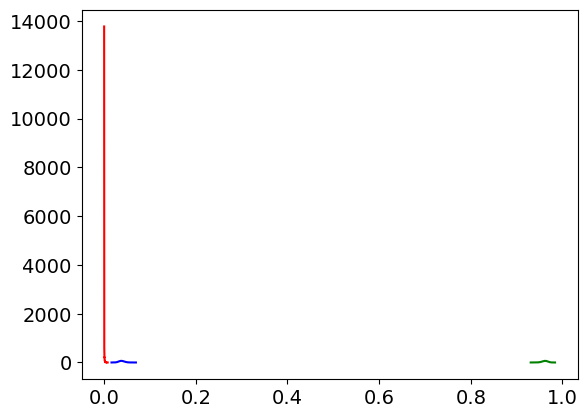

In [180]:
res = learn_edge_distribution(count_edges(edges)[('B', 'D')],
                        edge=['B', 'D'],
                        destination_folder="", 
                        experiment_identifier="", 
                        mcmc_alg=pm.NUTS, 
                        chains=10, 
                        burnin=1000, 
                        draws=5000, 
                        nthreads=10)

az.plot_dist(res["expected_fraction_of_observations"][:, 0], color='red');
az.plot_dist(res["expected_fraction_of_observations"][:, 1], color='b');
az.plot_dist(res["expected_fraction_of_observations"][:, 2], color='g');

Multiprocess sampling (10 chains in 10 jobs)
INFO:pymc.sampling.mcmc:Multiprocess sampling (10 chains in 10 jobs)
NUTS: [expected_fraction_of_observations, concentration]
INFO:pymc.sampling.mcmc:NUTS: [expected_fraction_of_observations, concentration]


Output()

Sampling 10 chains for 10_000 tune and 10_000 draw iterations (100_000 + 100_000 draws total) took 68 seconds.
INFO:pymc.sampling.mcmc:Sampling 10 chains for 10_000 tune and 10_000 draw iterations (100_000 + 100_000 draws total) took 68 seconds.


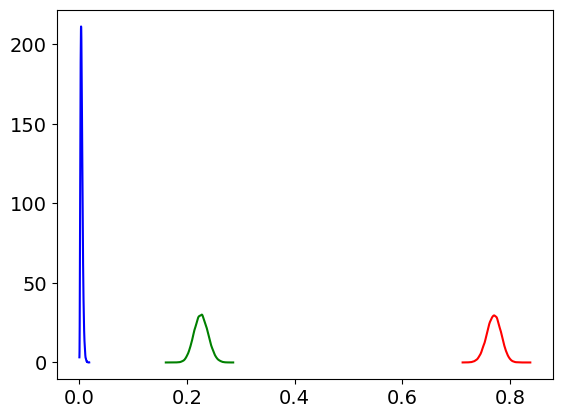

In [116]:
res = learn_edge_distribution(count_edges(edges)[('C', 'D')],
                        edge=['C', 'D'],
                        destination_folder="", 
                        experiment_identifier="", 
                        mcmc_alg=pm.NUTS, 
                        chains=10, 
                        burnin=10000, 
                        draws=10000, 
                        nthreads=10)

az.plot_dist(res["expected_fraction_of_observations"][:, 0], color='red');
az.plot_dist(res["expected_fraction_of_observations"][:, 1], color='b');
az.plot_dist(res["expected_fraction_of_observations"][:, 2], color='g');